In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin
import seaborn as sns
# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

In [29]:
# Lets adapt our model to include zenith angle

def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness, panel_angle_negative, zenith_angle, solar_zenith_angle):
    '''
    Models solar pnal output curve for one day based on NOAA ARO SPO GML Irradiance data
    This model function is like the old one but lets you put in the angle of the solar panel
    '''
    eff_direct = effs[0]
    eff_isotropic = effs[1]
    efficiency_back = .7

    # The angle the math uses to calculate is not the angle which makes sens for us to define our panel angle as so I correct for it as such
    angle_panel = 360 - panel_angle_negative
    Change_Time_1 = angle_panel/360*1440
    Change_Time_2 = Change_Time_1 + 1440/2
    Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
    Angular_Dependance_Back = np.array(-Angular_Dependance_Front)

    # create front of panel simulation (I did tricky math to get these)
    # Directional components:
    Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
    Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
    Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
    Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
    Tertiary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1-2*Change_Time_1+2*Change_Time_2)*sigmoid(-time, sharpness, Change_Time_2-(-2*Change_Time_1+2*Change_Time_2))
    Tertiary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2+4*Change_Time_2-4*Change_Time_1)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1-(+4*Change_Time_2-4*Change_Time_1))
    # Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back
    Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back + Tertiary_Back + Tertiary_Front
    
    
    # add directional to the isotropic components:
    Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance

    # Multiply by area to get total power
    Total_Power = Total_Irradiance*Area

    # constraint of device resistor:

    Max_Power = 420
    Total_Power = np.clip(Total_Power, 0, Max_Power)
    return Total_Power

In [30]:
# We have solved for the conversion factors for vertical panels in our vertical panel model notebooks. But these conversion factors are specifically for the angle between the sun and the panel when the panel is in the vertical orientation for the zenith angle the sun was at.
# We must then solve for a more universial conversion factor by deviding by cos(angle between panel normal vector and sun)
# We can do this because Power = ε_u * cos(angle between sun and panel) * Irradiance * Area of panel

# I have done this in Analysis/Model/Every_Day_Model.ipynb because that is where I do mutli day fitted statistics. I will copy the mean values for Direct and Isotropic over here





In [55]:
   #                                                                                                             
   #             ______________________                                          
   #            /_/_/_/_/_/_/_/_/_/_/_/                        
   #           /_/_/_/_/_/_/_/_/_/_/_/                         
   #          /_/_/_/_/_/_/_/_/_/_/_/                          
   #         /_/_/_/_/_/_/_/_/_/_/_/                          
                                                         
   #                                                   

Area = 2.0   # m**2
def Horizontal_Power_Monofacial(time, Direct_Irradiance, Diffuse_Irradaince, Upwelling_Irradiance, effs, solar_zenith_angle):
    '''this function is simulates the power output curve for a horizontal (laying flat) panel based on NOAA ARO SPO GML irradiance data'''
    direct_efficiency = effs[0]
    diffuse_efficiency = effs[1]
    Direct_Contribution = Direct_Irradiance*np.cos(solar_zenith_angle*np.pi/180)*direct_efficiency
    Diffuse_Contribution = Diffuse_Irradaince*diffuse_efficiency
    Total_Contribution  = (Direct_Contribution+Diffuse_Contribution)*Area
    return Total_Contribution # in W

    

In [56]:
# import NOAA data function
def Import_NOAA_Data(year, day):
    baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
    
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))
    
    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    #diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)

    '''Solar Zenith Angle'''
    NOAA_Zenith_1 = NOAA[0][7] 
    NOAA_Zenith_2 = NOAA[1][7]
    NZDT_Zenith= pd.concat([NOAA_Zenith_1.iloc[660:1440], NOAA_Zenith_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDT_Zenith = NZDT_Zenith.astype(float)
    #remove nan values from NZDTup_ir 
    NZDT_Zenith[NZDT_Zenith == -9999.9] = np.nan
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time, NZDT_Zenith


    

In [57]:


direct_irradiance, diffuse_irradiance, upwelling_irradiance, time, zenith = Import_NOAA_Data(25, 345)




https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25344.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25345.dat


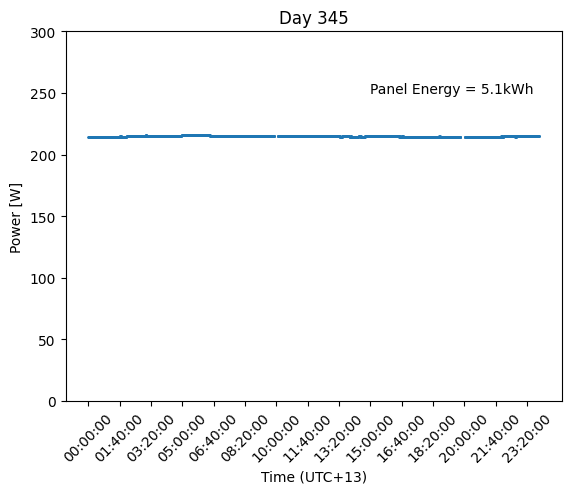

In [64]:


power_simulation = Horizontal_Power_Monofacial(time, direct_irradiance, diffuse_irradiance, upwelling_irradiance, [.25, .08], zenith)

plt.scatter(time, power_simulation, s = 1)
time_string = time.astype(str)
plt.xticks(time_string[::100], rotation = 45);
plt.xlabel('Time (UTC+13)')
plt.ylabel('Power [W]')
plt.title('Day 345')
integrated_power = trapezoid(np.nan_to_num(power_simulation,nan = 0),dx=60) # use dx = 60 because the NOAA data are in minutes not half minutes like ours
integrated_power_kWh = integrated_power/(1000*60**2)
plt.text(900,250,f'Panel Energy = {np.round(integrated_power_kWh,1)}kWh', fontsize = 10)
    
plt.ylim(0, 300)

plt.show()





In [80]:
   #                                                                                                             
   #             ______________________         ______________________                                   
   #            /_/_/_/_/_/_/_/_/_/_/_/         \_\_\_\_\_\_\_\_\_\_\_\               
   #           /_/_/_/_/_/_/_/_/_/_/_/  <----->  \_\_\_\_\_\_\_\_\_\_\_\              
   #          /_/_/_/_/_/_/_/_/_/_/_/             \_\_\_\_\_\_\_\_\_\_\_\             
   #         /_/_/_/_/_/_/_/_/_/_/_/               \_\_\_\_\_\_\_\_\_\_\_\           
                                                         
   #                                                   

Area = 2.0   # m**2
def Horizontal_Power_Bifacial(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, solar_zenith_angle):
    '''this function is simulates the power output curve for a horizontal (laying flat) panel based on NOAA ARO SPO GML irradiance data'''
    direct_efficiency = effs[0] # direct
    isotropic_efficiency = effs[1] # isotropic
    

    back_panel_efficiency = .7
    
    Direct_Contribution = Direct_Irradiance*np.cos(solar_zenith_angle*np.pi/180)*direct_efficiency
    Isotropic_contribution = ((Diffuse_Irradiance)+(Diffuse_Irradiance+Upwelling_Irradiance)*back_panel_efficiency)*isotropic_efficiency
    Total_Contribution  = (Direct_Contribution+Isotropic_contribution)*Area
    print(np.mean(Direct_Contribution))
    return Total_Contribution # in W


102.47749914707472
660    67.01
661    67.01
662    67.01
663    67.01
664    67.01
       ...  
655    66.93
656    66.93
657    66.93
658    66.93
659    66.93
Name: 7, Length: 1440, dtype: float64


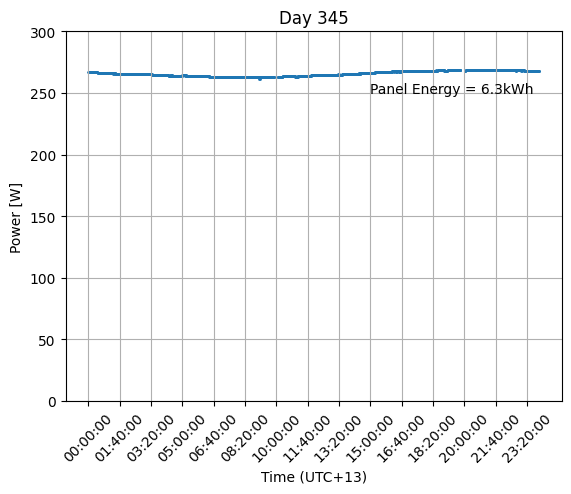

In [81]:
power_simulation = Horizontal_Power_Bifacial(time, direct_irradiance, diffuse_irradiance, upwelling_irradiance, [.25, .08], zenith)
print(zenith)
plt.scatter(time, power_simulation, s = 1)
time_string = time.astype(str)
plt.xticks(time_string[::100], rotation = 45);
plt.xlabel('Time (UTC+13)')
plt.ylabel('Power [W]')
plt.title('Day 345')
integrated_power = trapezoid(np.nan_to_num(power_simulation,nan = 0),dx=60) # use dx = 60 because the NOAA data are in minutes not half minutes like ours
integrated_power_kWh = integrated_power/(1000*60**2)
plt.text(900,250,f'Panel Energy = {np.round(integrated_power_kWh,1)}kWh', fontsize = 10)
    
plt.ylim(0, 300)
plt.grid('on')
plt.show()

